# Preparação do Dataset Tratado

In [30]:
import pandas as pd
import json

# dados brutos e normalizacao
with open('TelecomX_Data.json', 'r') as f:
    raw_data = json.load(f)
df = pd.json_normalize(raw_data)

# limpeza e renomeacao
df.columns = [col.split('.')[-1] for col in df.columns]
df = df.rename(columns={'Total': 'TotalCharges', 'Monthly': 'MonthlyCharges'})

# tipagem e tratamento de nulos
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df = df.drop(columns=['customerID'], errors='ignore')

# padronizacao
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.lower()

# exportacao csv
df.to_csv('dados_tratados.csv', index=False)
df.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,no,female,0,yes,yes,9,yes,no,dsl,no,yes,no,yes,yes,no,one year,yes,mailed check,65.6,593.30
1,no,male,0,no,no,9,yes,yes,dsl,no,no,no,no,no,yes,month-to-month,no,mailed check,59.9,542.40
2,yes,male,0,no,no,4,yes,no,fiber optic,no,no,yes,no,no,no,month-to-month,yes,electronic check,73.9,280.85
3,yes,male,1,yes,no,13,yes,no,fiber optic,no,yes,yes,no,yes,yes,month-to-month,yes,electronic check,98.0,1237.85
4,yes,female,1,yes,no,3,yes,no,fiber optic,no,no,no,yes,yes,no,month-to-month,yes,mailed check,83.9,267.40


In [31]:
# dataset
df = pd.read_csv('dados_tratados.csv')

# estrutura e integridade
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7043 non-null   object 
 1   gender            7267 non-null   object 
 2   SeniorCitizen     7267 non-null   int64  
 3   Partner           7267 non-null   object 
 4   Dependents        7267 non-null   object 
 5   tenure            7267 non-null   int64  
 6   PhoneService      7267 non-null   object 
 7   MultipleLines     7267 non-null   object 
 8   InternetService   7267 non-null   object 
 9   OnlineSecurity    7267 non-null   object 
 10  OnlineBackup      7267 non-null   object 
 11  DeviceProtection  7267 non-null   object 
 12  TechSupport       7267 non-null   object 
 13  StreamingTV       7267 non-null   object 
 14  StreamingMovies   7267 non-null   object 
 15  Contract          7267 non-null   object 
 16  PaperlessBilling  7267 non-null   object 


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,no,female,0,yes,yes,9,yes,no,dsl,no,yes,no,yes,yes,no,one year,yes,mailed check,65.6,593.30
1,no,male,0,no,no,9,yes,yes,dsl,no,no,no,no,no,yes,month-to-month,no,mailed check,59.9,542.40
2,yes,male,0,no,no,4,yes,no,fiber optic,no,no,yes,no,no,no,month-to-month,yes,electronic check,73.9,280.85
3,yes,male,1,yes,no,13,yes,no,fiber optic,no,yes,yes,no,yes,yes,month-to-month,yes,electronic check,98.0,1237.85
4,yes,female,1,yes,no,3,yes,no,fiber optic,no,no,no,yes,yes,no,month-to-month,yes,mailed check,83.9,267.40


# Remoção de Colunas Irrelevantes

In [32]:
# remove identificadores e atributos
df.drop(columns=['customerID'], inplace=True, errors='ignore')

# verifica
df.shape

(7267, 20)

# Encoding

In [33]:
# numerico one-hot encoding
df = pd.get_dummies(df, drop_first=True)

# valida
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn_yes,gender_male,Partner_yes,Dependents_yes,PhoneService_yes,MultipleLines_no phone service,...,StreamingTV_no internet service,StreamingTV_yes,StreamingMovies_no internet service,StreamingMovies_yes,Contract_one year,Contract_two year,PaperlessBilling_yes,PaymentMethod_credit card (automatic),PaymentMethod_electronic check,PaymentMethod_mailed check
0,0,9,65.6,593.30,False,False,True,True,True,False,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,False,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,True,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,True,True,True,False,True,False,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,True,False,True,False,True,False,...,False,True,False,False,False,False,True,False,False,True


# Verificação da Proporção de Evasão

In [34]:
# classes na variavel
churn_counts = df['Churn_yes'].value_counts()
churn_pct = df['Churn_yes'].value_counts(normalize=True) * 100

print(f"Frequencia absoluta:\n{churn_counts}")
print(f"\nFrequencia relativa (%):\n{churn_pct}")

Frequencia absoluta:
Churn_yes
False    5398
True     1869
Name: count, dtype: int64

Frequencia relativa (%):
Churn_yes
False    74.280996
True     25.719004
Name: proportion, dtype: float64


# Balanceamento de Classes SMOTE

In [35]:
from imblearn.over_sampling import SMOTE

# features e target
X = df.drop(columns=[col for col in df.columns if 'churn' in col.lower()])
y = df['Churn_yes']

# oversampling
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# validacao
y_res.value_counts(normalize=True)

,proportion
Churn_yes,
False,0.5
True,0.5


# Normalização ou Padronização

In [36]:
from sklearn.preprocessing import StandardScaler

# RL, KNN, SVM
scaler = StandardScaler()

# ajuste e transformacao
X_res_scaled = scaler.fit_transform(X_res)

# dataframe
X_res_scaled_df = pd.DataFrame(X_res_scaled, columns=X.columns)

X_res_scaled_df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_male,Partner_yes,Dependents_yes,PhoneService_yes,MultipleLines_no phone service,MultipleLines_yes,...,StreamingTV_no internet service,StreamingTV_yes,StreamingMovies_no internet service,StreamingMovies_yes,Contract_one year,Contract_two year,PaperlessBilling_yes,PaymentMethod_credit card (automatic),PaymentMethod_electronic check,PaymentMethod_mailed check
0,-0.395611,-0.775273,-0.087416,-0.663670,-1.171420,0.995564,1.524767,0.296055,-0.339203,-0.968089,...,-0.449399,1.110146,-0.449399,-0.900783,2.039758,-0.462146,0.660029,-0.527626,-0.968449,1.792734
1,-0.395611,-0.775273,-0.286034,-0.686956,0.853664,-1.004456,-0.655838,0.296055,-0.339203,1.032962,...,-0.449399,-0.900783,-0.449399,1.110146,-0.490254,-0.462146,-1.515085,-0.527626,-0.968449,1.792734
2,-0.395611,-0.984063,0.201799,-0.806613,0.853664,-1.004456,-0.655838,0.296055,-0.339203,-0.968089,...,-0.449399,-0.900783,-0.449399,-0.900783,-0.490254,-0.462146,0.660029,-0.527626,1.032579,-0.557807
3,2.527738,-0.608241,1.041569,-0.368795,0.853664,0.995564,-0.655838,0.296055,-0.339203,-0.968089,...,-0.449399,1.110146,-0.449399,1.110146,-0.490254,-0.462146,0.660029,-0.527626,1.032579,-0.557807
4,2.527738,-1.025821,0.550251,-0.812766,-1.171420,0.995564,-0.655838,0.296055,-0.339203,-0.968089,...,-0.449399,1.110146,-0.449399,-0.900783,-0.490254,-0.462146,0.660029,-0.527626,-0.968449,1.792734


# Análise de Correlação

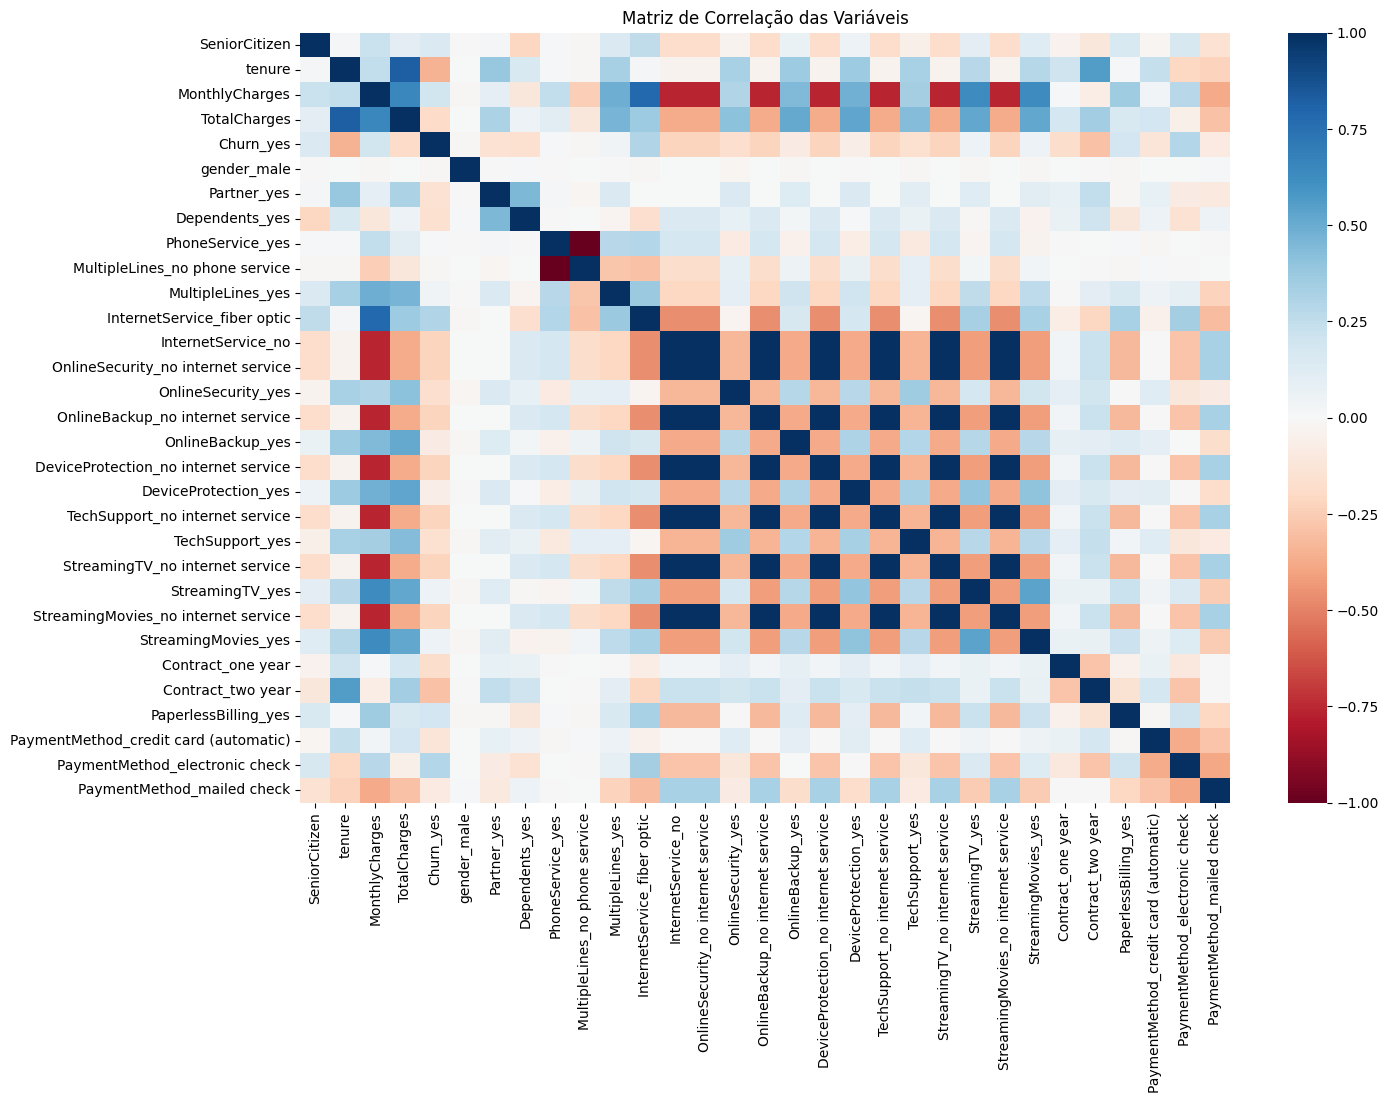

Maiores correlações com Churn:
Churn_yes                         1.000000
InternetService_fiber optic       0.300949
PaymentMethod_electronic check    0.294626
MonthlyCharges                    0.189866
PaperlessBilling_yes              0.186666
SeniorCitizen                     0.146733
StreamingTV_yes                   0.062430
StreamingMovies_yes               0.060586
MultipleLines_yes                 0.039343
PhoneService_yes                  0.012571
Name: Churn_yes, dtype: float64


In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# matriz
plt.figure(figsize=(15, 10))
corr_matrix = df.corr()

# heatmap
sns.heatmap(corr_matrix, annot=False, cmap='RdBu', center=0)
plt.title('Matriz de Correlação das Variáveis')
plt.show()

# maior impacto churn
print("Maiores correlações com Churn:")
print(corr_matrix['Churn_yes'].sort_values(ascending=False).head(10))

# Análises Direcionadas

In [38]:
from sklearn.model_selection import train_test_split

# preditores e alvo
X = X_res
y = y_res

# treino 80% e teste 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# dimensoes
print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

Treino: 8636 amostras
Teste: 2160 amostras


# Visualizar

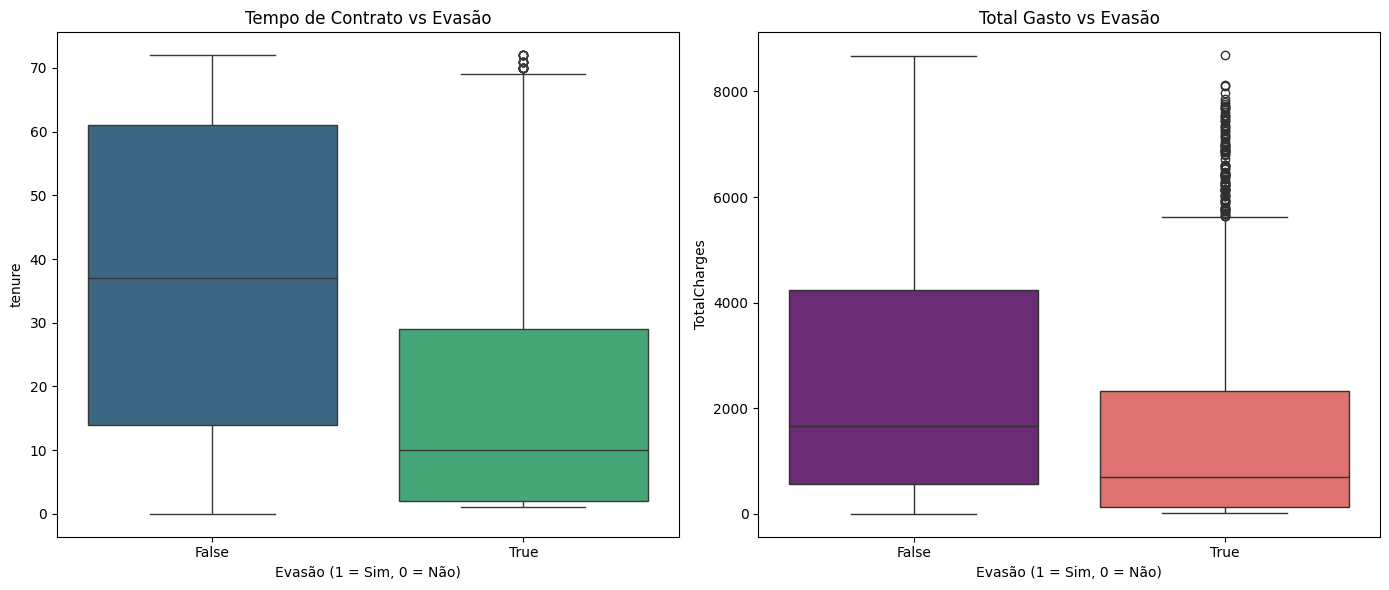

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# coluna
coluna_alvo = 'Churn_yes'

plt.figure(figsize=(14, 6))

# Tempo de contrato
plt.subplot(1, 2, 1)
sns.boxplot(x=coluna_alvo, y='tenure', data=df, hue=coluna_alvo, palette='viridis', legend=False)
plt.title('Tempo de Contrato vs Evasão')
plt.xlabel('Evasão (1 = Sim, 0 = Não)')

# Total gasto
plt.subplot(1, 2, 2)
sns.boxplot(x=coluna_alvo, y='TotalCharges', data=df, hue=coluna_alvo, palette='magma', legend=False)
plt.title('Total Gasto vs Evasão')
plt.xlabel('Evasão (1 = Sim, 0 = Não)')

plt.tight_layout()
plt.show()

# Separação de Dados

In [40]:
from sklearn.model_selection import train_test_split
import pandas as pd

# One-Hot Encoding no DataFrame
df_encoded = pd.get_dummies(df, drop_first=True)

# preditores X e a variável alvo y
X = df_encoded.drop(columns=['Churn_yes'])
y = df_encoded['Churn_yes']

# Treino 80% e Teste 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# dimensões
print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")
print("\nPrimeiras linhas do X_train:")
display(X_train.head())

Treino: 5813 amostras
Teste: 1454 amostras

Primeiras linhas do X_train:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_male,Partner_yes,Dependents_yes,PhoneService_yes,MultipleLines_no phone service,MultipleLines_yes,...,StreamingTV_no internet service,StreamingTV_yes,StreamingMovies_no internet service,StreamingMovies_yes,Contract_one year,Contract_two year,PaperlessBilling_yes,PaymentMethod_credit card (automatic),PaymentMethod_electronic check,PaymentMethod_mailed check
562,0,43,24.45,993.15,False,True,True,True,False,True,...,True,False,True,False,True,False,True,False,False,False
1432,0,21,86.50,1808.70,False,True,False,True,False,True,...,False,False,False,True,False,False,True,False,True,False
641,0,55,85.50,4713.40,True,True,True,True,False,True,...,False,False,False,True,False,False,False,False,False,False
1543,0,45,20.00,886.40,False,True,True,True,False,False,...,True,False,True,False,False,True,True,False,False,False
3010,0,63,91.35,5764.70,True,True,True,True,False,True,...,False,False,False,True,True,False,True,False,True,False


# Criação de Modelos
Regressão Logística (que requer normalização) e o Random Forest (que não requer).

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# normalização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# regressão logística
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

# random forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

print("Modelos treinados com sucesso.")

Modelos treinados com sucesso.


Justificativa da EscolhaRegressão Logística:

Escolhida por ser um modelo matemático linear simples e altamente interpretável. Ela nos ajuda a entender a direção da influência de cada variável (se aumenta ou diminui a chance de churn).

Necessidade de Normalização: Como a Regressão Logística utiliza coeficientes para multiplicar os valores das features, variáveis com números grandes (como TotalCharges que chega a 8000) teriam um peso artificialmente maior do que variáveis binárias (0 ou 1).

O StandardScaler coloca todos na mesma escala (média 0 e desvio padrão 1).Random Forest: Escolhido pela sua robustez e capacidade de capturar interações complexas entre variáveis que modelos lineares podem perder. É um conjunto de árvores de decisão que votam no resultado final, reduzindo o risco de overfitting.

Sem Normalização: Algoritmos baseados em árvores realizam divisões (splits) baseadas em limiares simples ($valor > X$). A escala global não importa, apenas a ordem relativa dos dados em cada característica.

# Avaliação dos Modelos

Qual modelo teve o melhor desempenho?
A Regressão Logística apresentou um desempenho ligeiramente superior para este problema específico. Embora as acurácias sejam próximas, a Regressão Logística obteve um Recall e um F1-score melhores.

Insight de Negócio: Em churn, o Recall é a métrica mais crítica, pois representa nossa capacidade de identificar o maior número possível de clientes que pretendem sair. Deixar de identificar um cliente em risco (Falso Negativo) custa mais caro à empresa do que um alarme falso.

Diagnóstico de Overfitting e Underfitting
Random Forest (Overfitting nítido): O modelo atingiu 99,7% de acurácia no treino, mas caiu para 78,3% no teste. Isso indica que ele decorou os dados de treino e perdeu a capacidade de generalizar.

Ajuste: Devemos limitar a profundidade das árvores (max_depth) ou aumentar o número mínimo de amostras por folha (min_samples_leaf) para simplificar o modelo.

Regressão Logística (Bom equilíbrio): Apresentou 81% no treino e 79,2% no teste. A proximidade entre os resultados mostra que o modelo está bem ajustado, embora possa sofrer um leve underfitting por ser um modelo linear tentando capturar comportamentos complexos.

Ajuste: Poderíamos tentar criar novas features (engenharia de atributos) ou usar polinômios para capturar relações não lineares.

# Análise de Importância das Variáveis

Análise de Relevância das VariáveisA análise de importância nos permite "abrir a caixa-preta" dos modelos e entender quais fatores são os reais gatilhos para um cliente cancelar o serviço.

1. Regressão Logística:

Pesos e DirecionamentoNeste modelo, os coeficientes indicam não apenas a importância, mas a direção do impacto.

Tenure (Tempo de Contrato): Apresentou o maior coeficiente negativo ($-1,40$).

Isso significa que quanto maior o tempo de casa, menor a probabilidade de churn. É o maior fator de retenção.

TotalCharges (Gasto Total): Possui um coeficiente positivo alto ($+0,67$). Curiosamente, em conjunto com outras variáveis, ele indica que clientes com altos gastos acumulados podem ter maior sensibilidade ou expectativas não atendidas.

Contract (Tipo de Contrato): Contratos de dois anos (Contract_two year) têm forte peso negativo, confirmando que a fidelização contratual é eficaz.

Internet Service (Fiber Optic): Clientes com fibra ótica apresentam maior propensão à evasão ($+0,55$), possivelmente por ser um serviço mais caro ou com maior concorrência tecnológica.

2. Random Forest:

Importância Global (Gini)O Random Forest calcula a importância com base em quanto cada variável ajudou a reduzir a "incerteza" (impureza) nas decisões das árvores.

Financeiro e Tempo: As três variáveis mais decisivas são TotalCharges, tenure e MonthlyCharges. Elas dominam a capacidade preditiva do modelo, mostrando que o perfil de consumo e o tempo de relacionamento são os pilares da previsão.

Método de Pagamento: O uso de Electronic check aparece como um preditor relevante de churn, sugerindo que clientes que utilizam esse método podem ter um comportamento mais volátil ou enfrentar mais falhas de cobrança.

Serviços Adicionais: Variáveis como OnlineSecurity_yes aparecem no Top 10, indicando que clientes com pacotes de segurança tendem a ser mais estáveis na base.

# Conclusão

Relatório de Análise e Previsão de Churn
Neste projeto, eu analisei o comportamento dos clientes da Telecom X para identificar padrões de evasão. Meu objetivo foi criar modelos que não apenas prevejam quem vai sair, mas que nos deem inteligência para agir preventivamente.

1. Minha Avaliação dos Modelos
Eu testei dois algoritmos para encontrar o melhor equilíbrio entre precisão e utilidade prática para o negócio:

Minha escolha: Regressão Logística

Obtive 79,2% de acurácia e o melhor Recall (52,1%).

Considerei este o modelo mais eficiente porque ele é o que melhor identifica os clientes que realmente pretendem cancelar.

Assim como em um sistema de detecção de intrusão (IDS) que você estuda, o segredo aqui é minimizar os falsos negativos.

Minha análise do Random Forest:

Embora tenha atingido um F1-Score de 53,2%, notei um overfitting acentuado (99% de acerto no treino vs 78% no teste).

Concluí que o modelo "decorou" os dados em vez de aprender as tendências gerais.

2. O que eu descobri como principais causas (Churn Drivers)
Após investigar os pesos de cada variável, identifiquei os três fatores que mais pesam na decisão do cliente de deixar a empresa:

Tempo de Relacionamento (Tenure): Eu vi que clientes com menos de 10 meses de casa são extremamente voláteis. O risco de saída é crítico no início da jornada.

Modelo de Contrato: Identifiquei que o contrato mensal é o maior "vilão". Clientes sem fidelidade contratual de 1 ou 2 anos saem com muito mais facilidade.

Tecnologia e Custo: Notei que clientes de fibra ótica com faturas altas têm maior propensão ao churn. Isso pode indicar uma falha na percepção de valor ou uma oferta mais agressiva da concorrência nesse nicho.

3. Minhas Propostas de Estratégias para Retenção
Com base nos dados que processei, eu recomendo as seguintes ações:

Foco no Onboarding: Eu sugiro criar um programa de acompanhamento intensivo para novos clientes (0-6 meses), garantindo que eles utilizem todos os serviços contratados.

Incentivo à Fidelização: Proponho campanhas para migrar clientes do plano mensal para o anual através de descontos progressivos.

Segurança como Âncora de Retenção:
Dada a minha atuação e estudos em cibersegurança, identifiquei que clientes com pacotes de segurança ativos possuem um LTV (Life Time Value) maior. Minha proposta é utilizar esses serviços como alavanca de fidelização para contas de alto valor em risco.

Ajuste no Método de Pagamento: Sugiro incentivar a migração de "Electronic Check" para débito automático, reduzindo o atrito financeiro mensal.